## Описание проекта

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики RMSE на тестовой выборке должно быть <b>не больше 48</b>.

## Инструкция по выполнению проекта
1. Загрузите данные и выполните их ресемплирование по одному часу.
2. Проанализируйте данные.
3. Обучите разные модели с различными гиперпараметрами. Сделайте тестовую выборку размером 10% от исходных данных.
4. Проверьте данные на тестовой выборке и сделайте выводы.

# 1. Загрузка, декомпозиция и анализ данных

In [1]:
import time
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

from lightgbm import LGBMRegressor 
from catboost import CatBoostRegressor

from sklearn.model_selection import TimeSeriesSplit, train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


rmse_scorer = make_scorer(rmse, greater_is_better=False)
RANDOM_STATE = 12345


In [2]:
data = pd.read_csv('taxi.csv', index_col=[0], parse_dates=[0])
data = data.sort_index()

In [3]:
display(data.head(20))
data.info()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32
2018-03-01 00:50:00,21
2018-03-01 01:00:00,7
2018-03-01 01:10:00,5
2018-03-01 01:20:00,17


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [4]:
# Выполняю ресемплирование данных по одному часу

data = data.resample('1h').sum()

data.index.min(), data.index.max()


(Timestamp('2018-03-01 00:00:00'), Timestamp('2018-08-31 23:00:00'))

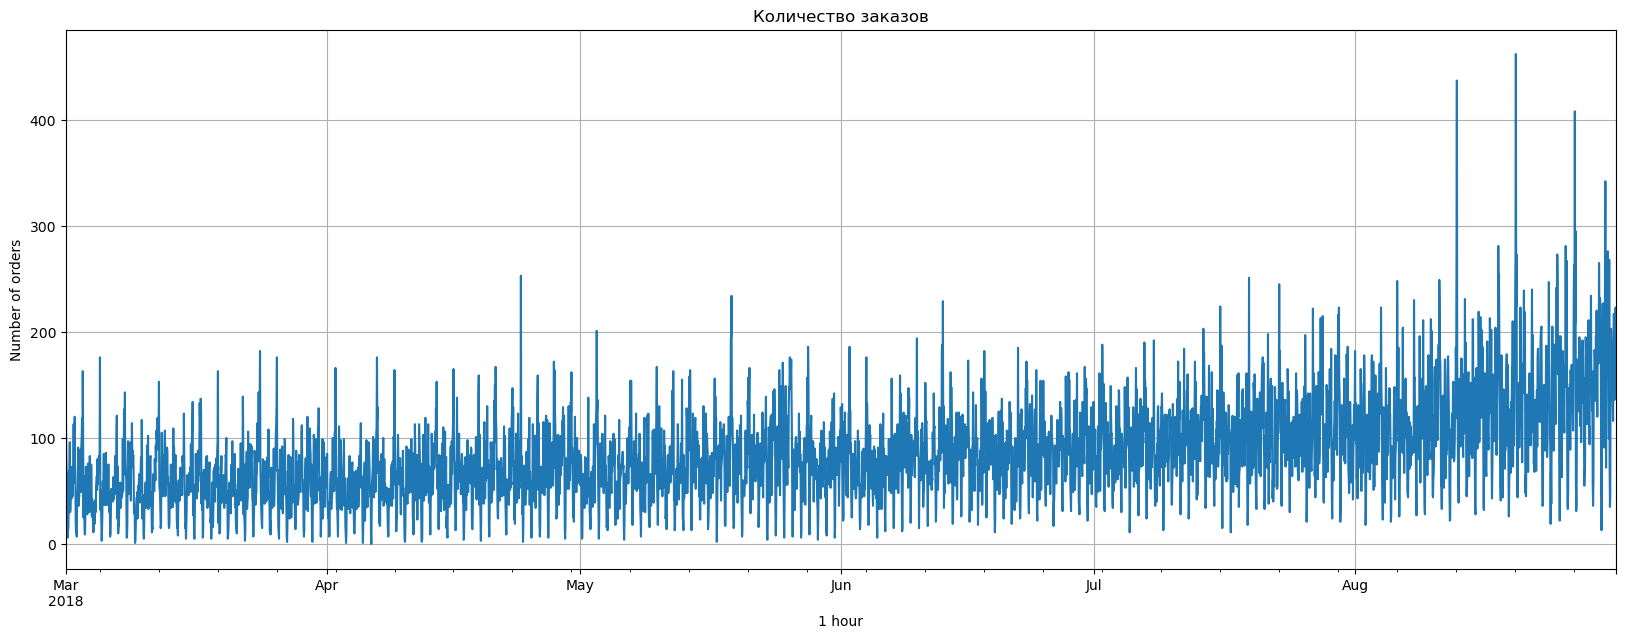

In [5]:
# Строю график по ресемплированным данным

data.plot(grid=True, legend=False, figsize=(20, 7), title='Количество заказов', xlabel='1 hour', ylabel='Number of orders')
plt.show()

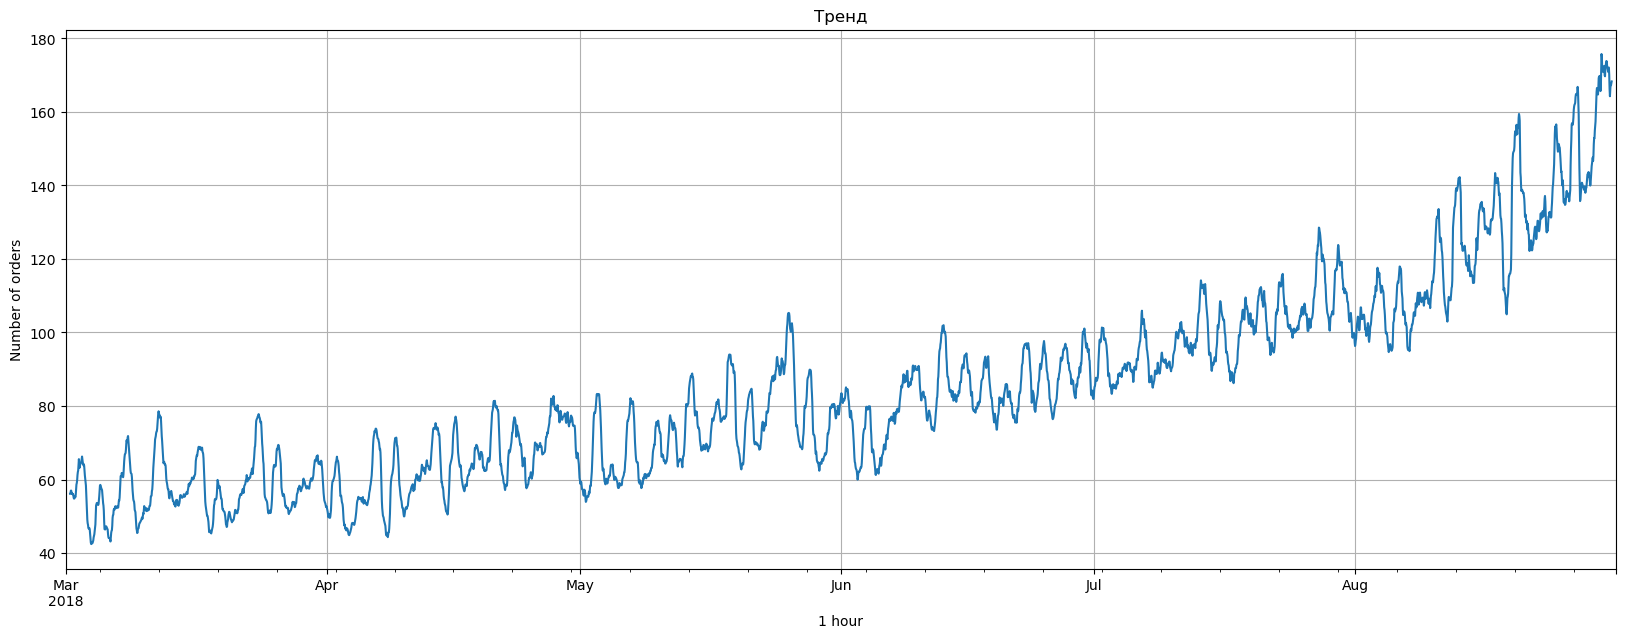

In [6]:
decomposed = seasonal_decompose(data)

decomposed.trend.plot(
    grid=True, 
    legend=False, 
    figsize=(20, 7), 
    title='Тренд', 
    xlabel='1 hour', 
    ylabel='Number of orders'
)
plt.show()

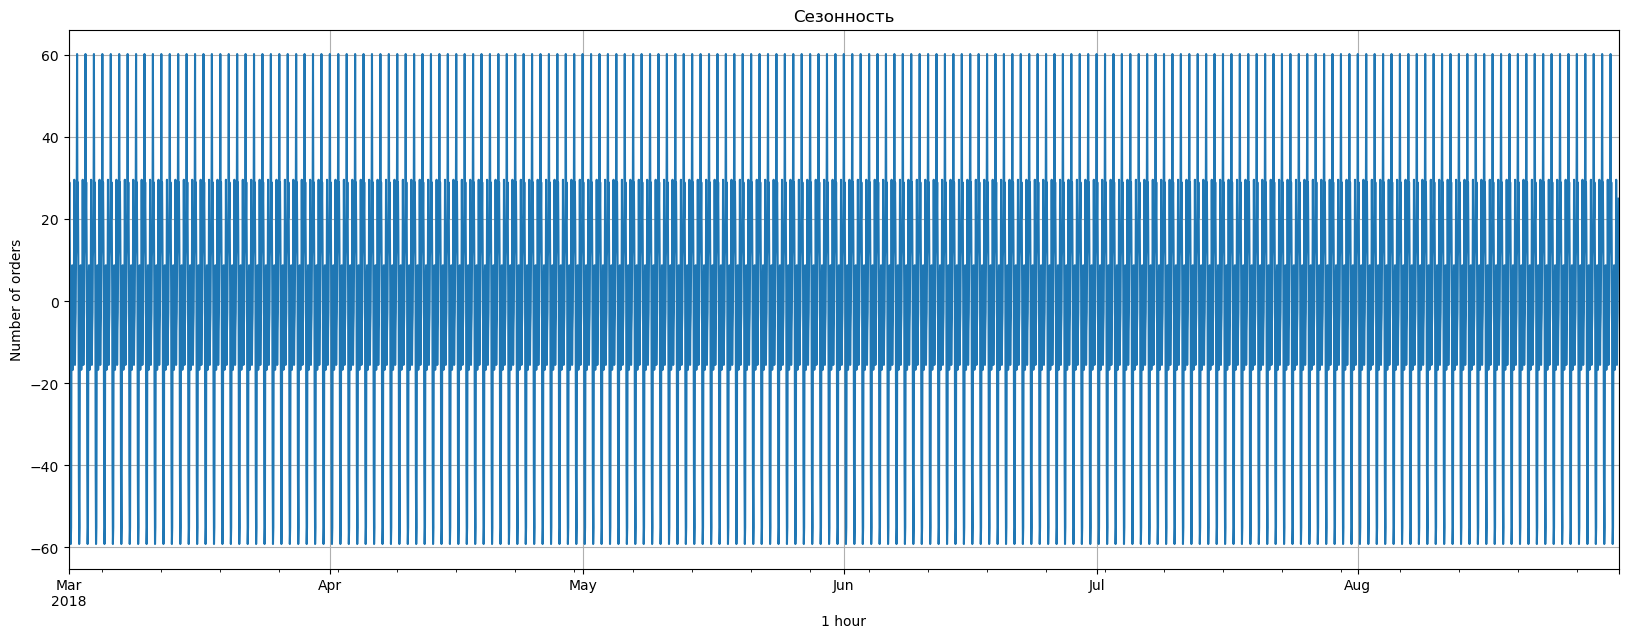

In [7]:
decomposed.seasonal.plot(
    grid=True, 
    legend=False, 
    figsize=(20, 7), 
    title='Сезонность', 
    xlabel='1 hour', 
    ylabel='Number of orders'
)
plt.show()

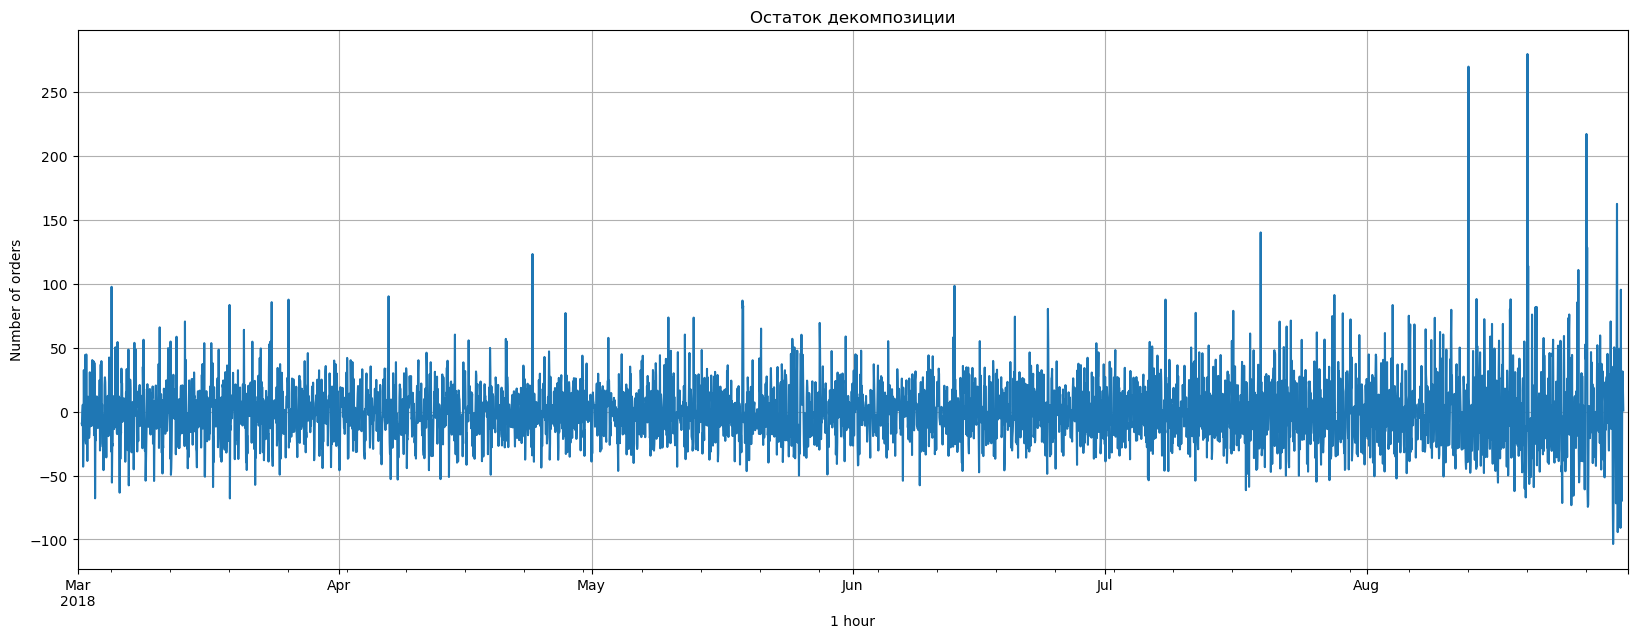

In [8]:
decomposed.resid.plot(
    grid=True, 
    legend=False, 
    figsize=(20, 7), 
    title='Остаток декомпозиции', 
    xlabel='1 hour', 
    ylabel='Number of orders'
)
plt.show()

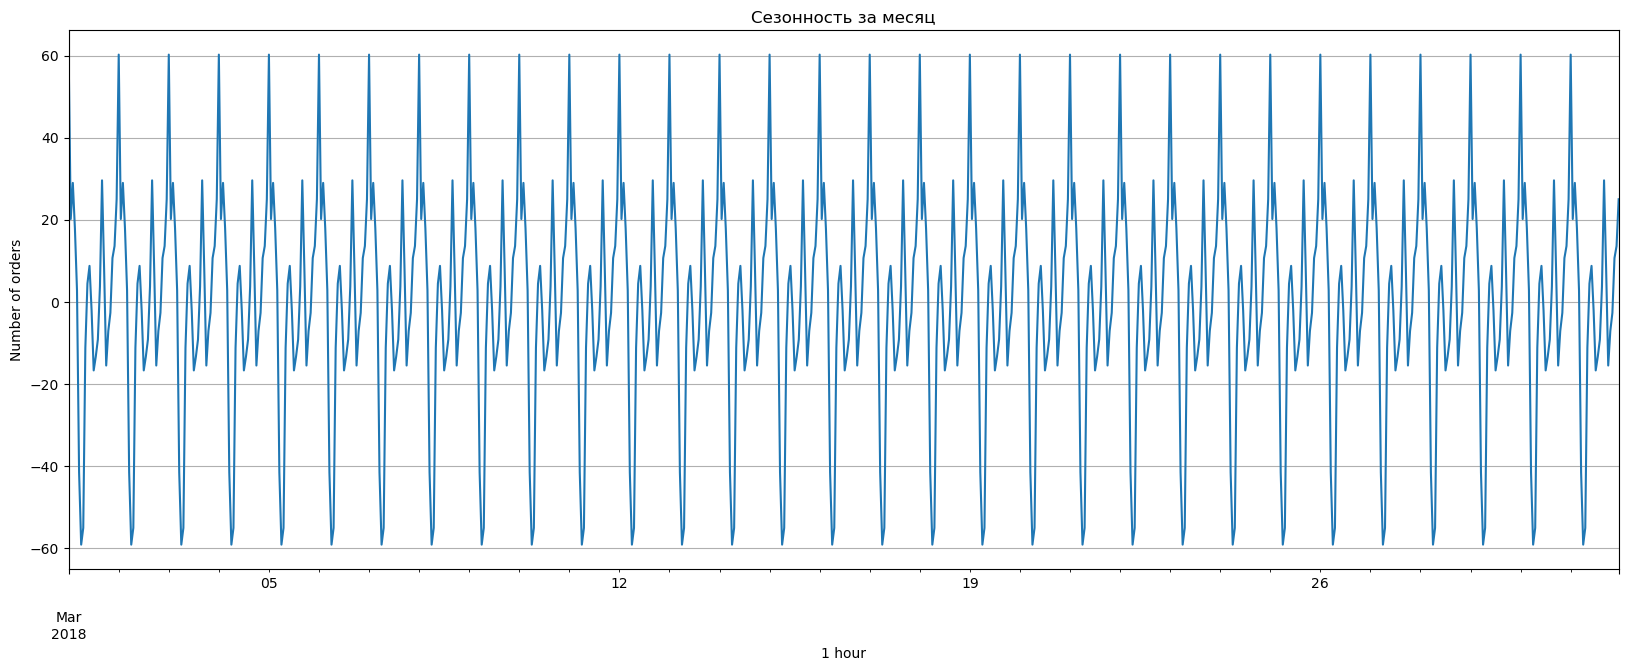

In [9]:
# Вывожу график с сезонностью за месяц

decomposed.seasonal['2018-03-01':'2018-03-31'].plot(
    grid=True, 
    legend=False, 
    figsize=(20, 7), 
    title='Сезонность за месяц', 
    xlabel='1 hour', 
    ylabel='Number of orders'
)
plt.show()

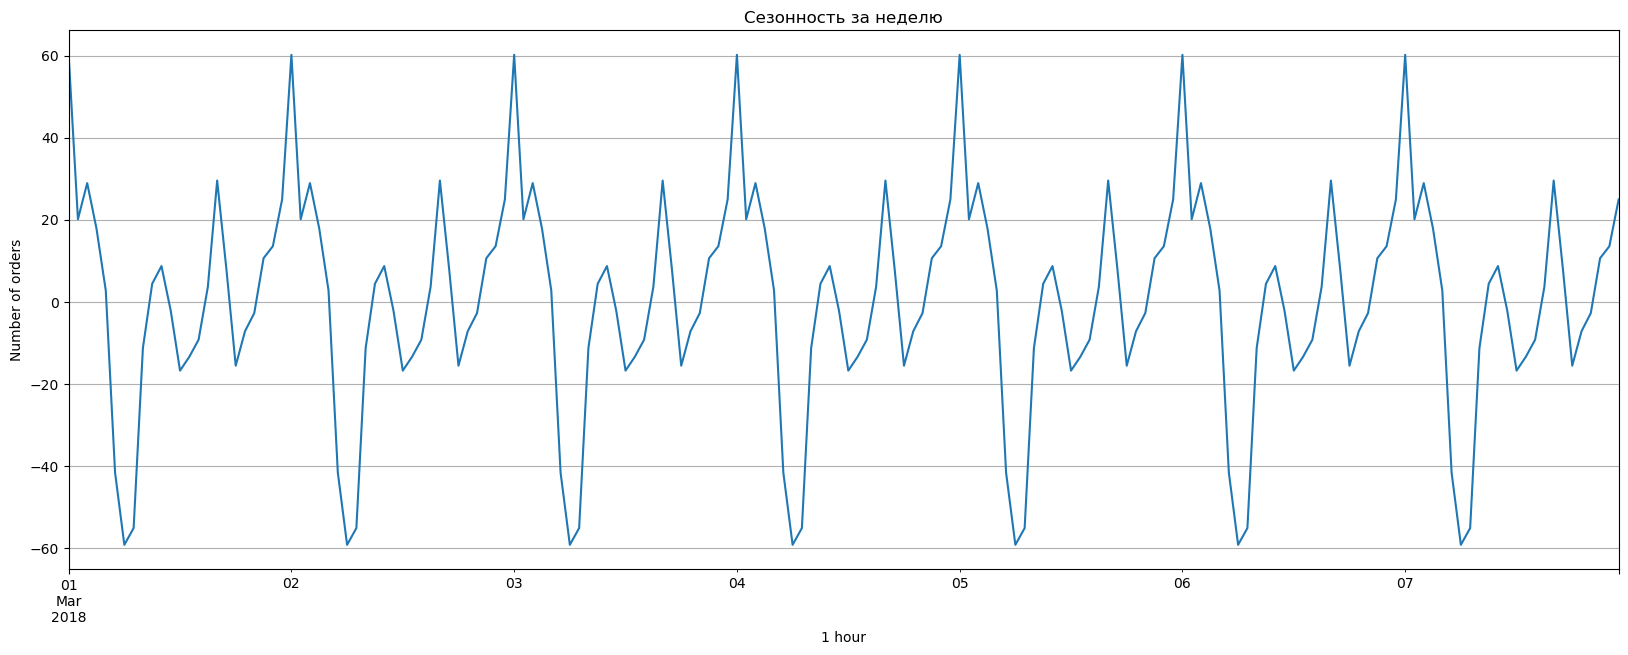

In [10]:
# Вывожу график с сезонностью за неделю

decomposed.seasonal['2018-03-01':'2018-03-07'].plot(
    grid=True, 
    legend=False, 
    figsize=(20, 7), 
    title='Сезонность за неделю', 
    xlabel='1 hour', 
    ylabel='Number of orders'
)
plt.show()

## Итоги декомпозиции данных

- На графиках количества заказов и трендов видно, что количество заказов постепенно возрастает.

- На графиках сезонности за месяц и за неделю можно заметить, что минимальное количество заказов - рано утром, а максимальное - ночью.


# 2. Создание признаков

## 2.1 Функция создания признаков

Исходный датафрейм `data` не изменяю напрямую. Все признаки создаются в отдельной функции, чтобы не было утечки данных и ошибок при повторном запуске ячеек.

In [11]:
def make_features(data, max_lag, rolling_mean_size):

    if max_lag is None or rolling_mean_size is None:
        raise ValueError('max_lag и rolling_mean_size должны быть числами, а не None.')

    max_lag = int(max_lag)
    rolling_mean_size = int(rolling_mean_size)

    if max_lag < 1:
        raise ValueError('max_lag должен быть положительным числом.')
    if rolling_mean_size < 1:
        raise ValueError('rolling_mean_size должен быть положительным числом.')

    data = data.copy()

    calendar_features = pd.DataFrame(index=data.index)
    calendar_features['month'] = data.index.month
    calendar_features['day'] = data.index.day
    calendar_features['dayofweek'] = data.index.dayofweek
    calendar_features['hour'] = data.index.hour

    lag_features = pd.concat(
        [data['num_orders'].shift(lag).rename(f'lag_{lag}') for lag in range(1, max_lag + 1)],
        axis=1
    )

    rolling_feature = (
        data['num_orders']
        .shift(1)
        .rolling(rolling_mean_size)
        .mean()
        .rename('rolling_mean')
    )

    data_features = pd.concat(
        [data['num_orders'], calendar_features, lag_features, rolling_feature],
        axis=1
    )

    return data_features.dropna()


## 2.2 Подбор параметров для признаков

Параметры подбираются только на обучающей части временного ряда. Тестовую выборку не используем при подборе, чтобы итоговая проверка оставалась честной.

In [12]:
# Отделяю тестовую часть заранее.
# Она не участвует в подборе параметров признаков.

data_train_raw, data_test_raw = train_test_split(
    data,
    shuffle=False,
    test_size=0.1
)

tscv = TimeSeriesSplit(n_splits=5)
model_for_features = LinearRegression()

results_features = []

max_lag_values = [1, 6, 12, 24, 48, 72, 96]
rolling_mean_values = [3, 6, 12, 24, 48]

for max_lag in max_lag_values:
    for rolling_mean_size in rolling_mean_values:

        data_features = make_features(
            data_train_raw,
            max_lag=max_lag,
            rolling_mean_size=rolling_mean_size
        )

        features_cv = data_features.drop('num_orders', axis=1)
        target_cv = data_features['num_orders']

        scores = cross_val_score(
            model_for_features,
            features_cv,
            target_cv,
            scoring=rmse_scorer,
            cv=tscv
        )

        results_features.append({
            'max_lag': max_lag,
            'rolling_mean_size': rolling_mean_size,
            'rmse_cv': -scores.mean()
        })

results_features = (
    pd.DataFrame(results_features)
    .sort_values('rmse_cv')
    .reset_index(drop=True)
)

display(results_features.head(10))

best_max_lag = int(results_features.loc[0, 'max_lag'])
best_rolling_mean_size = int(results_features.loc[0, 'rolling_mean_size'])
best_rmse_features = results_features.loc[0, 'rmse_cv']

print('Лучшие параметры для признаков:')
print('max_lag:', best_max_lag)
print('rolling_mean_size:', best_rolling_mean_size)
print('RMSE на кросс-валидации:', round(best_rmse_features, 2))


,max_lag,rolling_mean_size,rmse_cv
0,96,3,23.856790
1,96,6,23.856790
2,96,48,23.856790
3,96,12,23.856790
4,96,24,23.856790
5,72,12,24.016525
6,72,48,24.016525
7,72,6,24.016525
8,72,3,24.016525
9,72,24,24.016525


Лучшие параметры для признаков:
max_lag: 96
rolling_mean_size: 3
RMSE на кросс-валидации: 23.86


## Итоги создания признаков

Для прогноза количества заказов были созданы следующие признаки:

- календарные признаки: месяц, день, день недели и час;
- лаговые признаки, которые показывают количество заказов в предыдущие часы;
- скользящее среднее, рассчитанное только по прошлым значениям временного ряда.

Параметры признаков подбирались только на обучающей части данных с помощью `TimeSeriesSplit`. Тестовая выборка при подборе не использовалась.

Оптимальные параметры функции `make_features` в текущем запуске:

- `max_lag`: <b>96</b>;
- `rolling_mean_size`: <b>3</b>.

Лучшее значение RMSE на кросс-валидации при подборе признаков составило примерно <b>23.86</b>. После создания признаков в данных осталось <b>4320</b> наблюдений и <b>102</b> столбца.

## 2.3 Создание финальной таблицы признаков

In [13]:
# Создаю признаки с лучшими найденными параметрами

data = make_features(
    data,
    max_lag=best_max_lag,
    rolling_mean_size=best_rolling_mean_size
)

data.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4320 entries, 2018-03-05 00:00:00 to 2018-08-31 23:00:00
Freq: h
Columns: 102 entries, num_orders to rolling_mean
dtypes: float64(97), int32(4), int64(1)
memory usage: 3.3 MB


# 3. Обучение разных моделей с различными гиперпараметрами  и их анализ

In [14]:
# Создаю обучающую и тестовую выборки

features = data.drop('num_orders', axis=1)
target = data['num_orders']

features_train, features_test, target_train, target_test = train_test_split(
    features,
    target,
    shuffle=False,
    test_size=0.1
)

print('Размер обучающей выборки:', features_train.shape)
print('Размер тестовой выборки:', features_test.shape)


Размер обучающей выборки: (3888, 101)
Размер тестовой выборки: (432, 101)


In [15]:
# Вспомогательная функция для измерения времени обучения и предсказания

def fit_predict_with_time(model, features_train, target_train, features_test):
    start_fit = time.perf_counter()

    if isinstance(model, CatBoostRegressor):
        model.fit(features_train, target_train, verbose=False)
    else:
        model.fit(features_train, target_train)

    fit_time = time.perf_counter() - start_fit

    start_predict = time.perf_counter()
    predictions = model.predict(features_test)
    predict_time = time.perf_counter() - start_predict

    return model, predictions, fit_time, predict_time


model_metrics = []
test_predictions = {}


## Линейная регрессия

In [16]:
# Обучаю линейную регрессию и оцениваю качество на кросс-валидации

model_1 = LinearRegression()

model_1_scores = cross_val_score(
    model_1,
    features_train,
    target_train,
    scoring=rmse_scorer,
    cv=tscv
)

model_1_rmse_cv = -model_1_scores.mean()

model_1, pred_model_1, fit_time, predict_time = fit_predict_with_time(
    model_1,
    features_train,
    target_train,
    features_test
)

model_metrics.append({
    'Модель': 'LinearRegression',
    'RMSE CV': model_1_rmse_cv,
    'Время обучения, сек.': fit_time,
    'Время предсказания, сек.': predict_time
})

test_predictions['LinearRegression'] = pred_model_1

print('RMSE LinearRegression на кросс-валидации:', round(model_1_rmse_cv, 2))


RMSE LinearRegression на кросс-валидации: 23.89


## RandomForestRegressor

In [17]:
# Подбираю гиперпараметры случайного леса

model_2_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

parameters_grid_0 = {
    'max_depth': [10, 20, None],
    'n_estimators': [100, 200]
}

model_2_grid_cross_val = GridSearchCV(
    model_2_base,
    parameters_grid_0,
    cv=tscv,
    scoring=rmse_scorer,
    n_jobs=-1
)

model_2_grid_cross_val.fit(features_train, target_train)

model_2_rmse_cv = -model_2_grid_cross_val.best_score_
model_2 = model_2_grid_cross_val.best_estimator_

print('Лучший RMSE RandomForestRegressor на кросс-валидации:', round(model_2_rmse_cv, 2))
print('Лучшие параметры:', model_2_grid_cross_val.best_params_)


Лучший RMSE RandomForestRegressor на кросс-валидации: 24.01
Лучшие параметры: {'max_depth': None, 'n_estimators': 200}


In [18]:
# Обучаю случайный лес с лучшими параметрами

model_2, pred_model_2, fit_time, predict_time = fit_predict_with_time(
    model_2,
    features_train,
    target_train,
    features_test
)

model_metrics.append({
    'Модель': 'RandomForestRegressor',
    'RMSE CV': model_2_rmse_cv,
    'Время обучения, сек.': fit_time,
    'Время предсказания, сек.': predict_time
})

test_predictions['RandomForestRegressor'] = pred_model_2


## LGBMRegressor

In [19]:
# Подбираю гиперпараметры LGBMRegressor

LGBM_model = LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)

parameters_grid_1 = {
    'max_depth': [2, 6, 10],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

LGBM_grid_cross_val = GridSearchCV(
    LGBM_model,
    parameters_grid_1,
    cv=tscv,
    scoring=rmse_scorer,
    n_jobs=-1
)

LGBM_grid_cross_val.fit(features_train, target_train)

model_LGBM_rmse_cv = -LGBM_grid_cross_val.best_score_
model_LGBM = LGBM_grid_cross_val.best_estimator_

print('Лучший RMSE LGBMRegressor на кросс-валидации:', round(model_LGBM_rmse_cv, 2))
print('Лучшие параметры:', LGBM_grid_cross_val.best_params_)


Лучший RMSE LGBMRegressor на кросс-валидации: 23.71
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}


In [20]:
# Обучаю LGBMRegressor с лучшими параметрами

model_LGBM, predictions_LGBM, fit_time, predict_time = fit_predict_with_time(
    model_LGBM,
    features_train,
    target_train,
    features_test
)

model_metrics.append({
    'Модель': 'LGBMRegressor',
    'RMSE CV': model_LGBM_rmse_cv,
    'Время обучения, сек.': fit_time,
    'Время предсказания, сек.': predict_time
})

test_predictions['LGBMRegressor'] = predictions_LGBM


## CatBoostRegressor

In [21]:
# Подбираю гиперпараметры CatBoostRegressor

CatBoost_model = CatBoostRegressor(
    random_state=RANDOM_STATE,
    loss_function='RMSE',
    verbose=False,
    allow_writing_files=False
)

parameters_grid_2 = {
    'depth': [4, 6],
    'learning_rate': [0.03, 0.1],
    'l2_leaf_reg': [1, 3],
    'iterations': [100, 200]
}

CatBoost_grid_cross_val = GridSearchCV(
    CatBoost_model,
    parameters_grid_2,
    cv=tscv,
    scoring=rmse_scorer,
    n_jobs=-1
)

CatBoost_grid_cross_val.fit(features_train, target_train)

model_CatBoost_rmse_cv = -CatBoost_grid_cross_val.best_score_
model_CatBoost = CatBoost_grid_cross_val.best_estimator_

print('Лучший RMSE CatBoostRegressor на кросс-валидации:', round(model_CatBoost_rmse_cv, 2))
print('Лучшие параметры:', CatBoost_grid_cross_val.best_params_)


Лучший RMSE CatBoostRegressor на кросс-валидации: 23.6
Лучшие параметры: {'depth': 6, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.1}


In [22]:
# Обучаю CatBoostRegressor с лучшими параметрами

model_CatBoost, predictions_CatBoost, fit_time, predict_time = fit_predict_with_time(
    model_CatBoost,
    features_train,
    target_train,
    features_test
)

model_metrics.append({
    'Модель': 'CatBoostRegressor',
    'RMSE CV': model_CatBoost_rmse_cv,
    'Время обучения, сек.': fit_time,
    'Время предсказания, сек.': predict_time
})

test_predictions['CatBoostRegressor'] = predictions_CatBoost


In [23]:
# Сравниваю модели по качеству на кросс-валидации и скорости

results = (
    pd.DataFrame(model_metrics)
    .sort_values('RMSE CV')
    .reset_index(drop=True)
)

display(results)

best_model_name = results.loc[0, 'Модель']
best_cv_rmse = results.loc[0, 'RMSE CV']

print('Лучшая модель по кросс-валидации:', best_model_name)
print('RMSE лучшей модели на кросс-валидации:', round(best_cv_rmse, 2))


,Модель,RMSE CV,"Время обучения, сек.","Время предсказания, сек."
0,CatBoostRegressor,23.602143,1.110869,0.003124
1,LGBMRegressor,23.708750,0.189788,0.002768
2,LinearRegression,23.885813,0.008133,0.001142
3,RandomForestRegressor,24.006236,4.345727,0.040551


Лучшая модель по кросс-валидации: CatBoostRegressor
RMSE лучшей модели на кросс-валидации: 23.6


## Итоги подбора параметров и обучения моделей

Модели сравнивались по метрике RMSE на кросс-валидации с `TimeSeriesSplit`. Для временных рядов это корректнее обычной случайной кросс-валидации, потому что порядок наблюдений сохраняется: модель обучается на более ранних данных и проверяется на более поздних.

Показатели RMSE на кросс-валидации в текущем запуске, от лучшей модели к худшей:

1. `CatBoostRegressor`: <b>23.60</b>;
2. `LGBMRegressor`: <b>23.71</b>;
3. `LinearRegression`: <b>23.89</b>;
4. `RandomForestRegressor`: <b>24.01</b>.

По качеству на кросс-валидации лучшей моделью стала <b>CatBoostRegressor</b>. Разница между моделями небольшая, но CatBoost показал минимальное значение RMSE.

По скорости обучения самой быстрой моделью оказалась `LinearRegression`, но её качество немного хуже, чем у бустинговых моделей. `RandomForestRegressor` обучался заметно дольше остальных и при этом не дал лучшего качества.

# 4. Проверка лучшей модели на тестовой выборке

In [24]:
# Проверяю качество моделей на тестовой выборке

test_results = []

for model_name, prediction in test_predictions.items():
    test_results.append({
        'Модель': model_name,
        'RMSE test': rmse(target_test, prediction)
    })

test_results = (
    pd.DataFrame(test_results)
    .sort_values('RMSE test')
    .reset_index(drop=True)
)

display(test_results)

best_model_test_rmse = rmse(target_test, test_predictions[best_model_name])

print('Лучшая модель по кросс-валидации:', best_model_name)
print('RMSE этой модели на тестовой выборке:', round(best_model_test_rmse, 2))

if best_model_test_rmse <= 48:
    print('Целевой порог RMSE ≤ 48 выполнен.')
else:
    print('Целевой порог RMSE ≤ 48 не выполнен.')


,Модель,RMSE test
0,LGBMRegressor,38.488356
1,CatBoostRegressor,38.945969
2,RandomForestRegressor,41.136725
3,LinearRegression,41.911897


Лучшая модель по кросс-валидации: CatBoostRegressor
RMSE этой модели на тестовой выборке: 38.95
Целевой порог RMSE ≤ 48 выполнен.


## Итоги проверки модели на тестовой выборке

Финальная оценка качества выполнялась только на тестовой выборке. Целевой порог проекта — RMSE не выше <b>48</b> заказов.

Показатели RMSE на тестовой выборке в текущем запуске:

1. `LGBMRegressor`: <b>38.49</b>;
2. `CatBoostRegressor`: <b>38.95</b>;
3. `RandomForestRegressor`: <b>41.14</b>;
4. `LinearRegression`: <b>41.91</b>.

Модель, выбранная по кросс-валидации, — <b>CatBoostRegressor</b>. На тестовой выборке её RMSE составил примерно <b>38.95</b>, что меньше требуемого порога <b>48</b>. Следовательно, задача проекта выполнена.

При этом `LGBMRegressor` на тестовой выборке показал чуть лучшее значение RMSE — около <b>38.49</b>. Разница между LGBM и CatBoost небольшая, поэтому обе модели можно считать успешными для данной задачи.

In [25]:
def plot_actual_predict(actual, prediction, title='Факт и прогноз количества заказов такси'):
    prediction = pd.Series(prediction, index=actual.index)

    plt.figure(figsize=(16, 7))
    plt.plot(actual, color='steelblue', linestyle='-', label='Факт')
    plt.plot(prediction, color='red', linestyle='--', label='Прогноз')
    plt.title(title)
    plt.xlabel('Дата и время')
    plt.ylabel('Число заказов')
    plt.grid(True)
    plt.legend()
    plt.show()


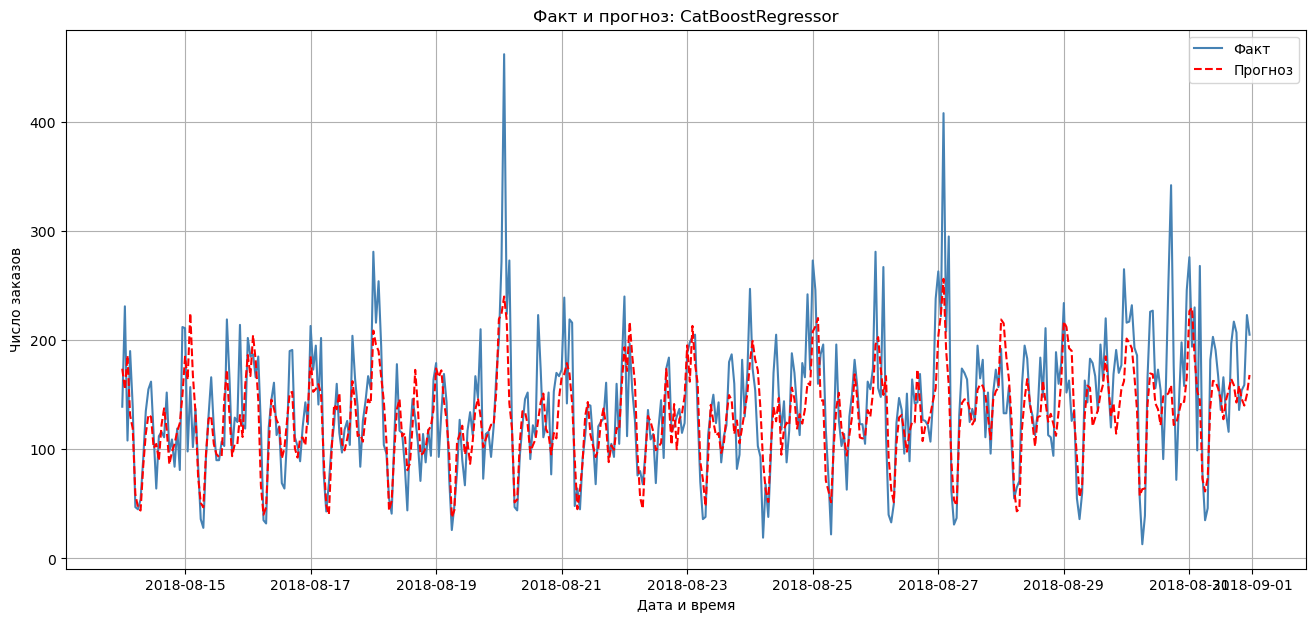

In [26]:
# Строю график для модели, выбранной по кросс-валидации

plot_actual_predict(
    target_test,
    test_predictions[best_model_name],
    title=f'Факт и прогноз: {best_model_name}'
)


# 5. Вывод

В проекте был построен прогноз количества заказов такси на следующий час. Цель проекта — получить модель с RMSE не выше <b>48</b> заказов на тестовой выборке.

## Итоги декомпозиции данных

- После ресемплирования данные были приведены к интервалу в один час.
- На графиках количества заказов и тренда видно, что спрос на такси постепенно возрастает.
- На графиках сезонности заметна суточная закономерность: минимальное количество заказов наблюдается рано утром, а максимальная нагрузка приходится на ночные часы.

## Итоги создания признаков

Для обучения моделей были созданы календарные признаки, лаги и скользящее среднее. Чтобы избежать утечки данных, скользящее среднее рассчитывалось только по прошлым значениям ряда через `shift(1)`.

Оптимальные параметры признаков в текущем запуске:

- `max_lag`: <b>96</b>;
- `rolling_mean_size`: <b>3</b>.

Подбор параметров выполнялся только на обучающей части данных с использованием `TimeSeriesSplit`.

## Итоги обучения моделей

Были обучены и сравнены четыре модели:

1. `LinearRegression`;
2. `RandomForestRegressor`;
3. `LGBMRegressor`;
4. `CatBoostRegressor`.

Результаты RMSE на кросс-валидации:

1. `CatBoostRegressor`: <b>23.60</b>;
2. `LGBMRegressor`: <b>23.71</b>;
3. `LinearRegression`: <b>23.89</b>;
4. `RandomForestRegressor`: <b>24.01</b>.

Лучшей моделью по кросс-валидации стала <b>CatBoostRegressor</b>.

## Итоги проверки на тестовой выборке

На тестовой выборке были получены следующие значения RMSE:

1. `LGBMRegressor`: <b>38.49</b>;
2. `CatBoostRegressor`: <b>38.95</b>;
3. `RandomForestRegressor`: <b>41.14</b>;
4. `LinearRegression`: <b>41.91</b>.

Финальная модель, выбранная по кросс-валидации, — <b>CatBoostRegressor</b>. Её RMSE на тестовой выборке составил примерно <b>38.95</b>, что меньше требуемого значения <b>48</b>. Значит, модель успешно решает задачу прогнозирования количества заказов такси на следующий час.

Также стоит отметить, что `LGBMRegressor` показал на тестовой выборке немного лучший результат — RMSE около <b>38.49</b>. Поэтому для практического использования можно рассматривать обе модели: `CatBoostRegressor` как модель, выбранную по кросс-валидации, и `LGBMRegressor` как самую сильную по тестовой метрике в данном запуске.